Defining activation functions

In [1]:
import numpy as np

In [2]:
def relu(x):
    return np.maximum(0,x)

In [3]:
def relu_derivative(x):
    return (x>0).astype(float)
    

In [4]:
def sigmoid (x):
    return 1/(1 + np.exp(-x))

In [5]:
def sigmoid_derivative (x):
    s = sigmoid(x)
    return s*(1-s)

In [6]:
def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)

Loss function - cross entropy, (also mse if you want to use)

In [7]:
def mse(predictions, labels):
    return np.mean((predictions - labels) ** 2) / 2


In [8]:
def mse_derivative(predictions, labels):
    return (predictions - labels) / predictions.shape[0]


In [9]:
def cross_entropy(predictions, labels):
    m = labels.shape[0]
    p = np.clip(predictions, 1e-15, 1 - 1e-15)
    log_likelihood = -np.log(p[range(m), labels])
    loss = np.sum(log_likelihood) / m
    return loss


In [10]:
def cross_entropy_derivative(predictions, labels):
    m = labels.shape[0]
    grad = predictions.copy()
    grad[range(m), labels] -= 1
    grad /= m
    return grad


Fully Connected Layer (from scratch)

In [11]:
class FullyConnectedLayer:
    def __init__(self, input_dim, output_dim): # input and output neurons number
        self.w = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)  #weight matrix (with random values)
        self.b = np.zeros((1, output_dim)) # bias matrix (with zeros)
        
    def forward(self, x):
        self.x = x  # save input for use in backprop, making it a part of class when we call the function.?
        self.z = x.dot(self.w) + self.b # calculating weighted sum, dot is dot product of vectors.
        return self.z

    def backward(self, grad_output, lr): #gradient of the loss with respect to this layer’s output, learning rate
        grad_w = self.x.T.dot(grad_output)  # shape: (input_dim, output_dim), gradient weights
        grad_b = np.sum(grad_output, axis=0, keepdims=True)  # shape: (1, output_dim), gradient bias
        grad_input = grad_output.dot(self.w.T)  # for earlier layer, gradient which needs to be passed back

        # Update weights and biases, acccr to gd formula
        self.w -= lr * grad_w
        self.b -= lr * grad_b

        return grad_input


Neural Network

In [12]:
class NeuralNetwork:
    def __init__(self, input_dim, hidden_dims, output_dim):
        dims = [input_dim] + hidden_dims + [output_dim]
        self.layers = [] # list of fullyconnected layers
        self.activations = [] # list of activations for each layer

        for i in range(len(dims) - 1):
            self.layers.append(FullyConnectedLayer(dims[i], dims[i + 1]))
            if i < len(dims) - 2: # if not last layer, use relu
                self.activations.append("relu")
            else: # use softmax for last layer
                self.activations.append("softmax")

    def forward(self, x): # x is first activation
        self.a = [x]  # store activations
        for i, layer in enumerate(self.layers): # looping through each fully connected layers, and getting their activations into a 
            z = layer.forward(self.a[-1])
            if self.activations[i] == "relu":
                a = relu(z)
            elif self.activations[i] == "sigmoid":
                a = sigmoid(z)
            elif self.activations[i] == "softmax":
                a = softmax(z)
            self.a.append(a)
        return self.a[-1] # output of neural network.

    def backward(self, y_true, lr):
        grad = cross_entropy_derivative(self.a[-1], y_true)  # ∂L/∂a for output layer, starting point of backward
        for i in reversed(range(len(self.layers))):
            if self.activations[i] == "relu":
                grad = relu_derivative(self.layers[i].z) * grad
            elif self.activations[i] == "sigmoid":
                grad = sigmoid_derivative(self.layers[i].z) * grad
            grad = self.layers[i].backward(grad, lr) # updating each weight and bias accr to grad we calculated for that layer

    def predict(self, x):
        probs = self.forward(x) # running forward pass to get predicted possibilities
        return np.argmax(probs, axis=1) # for each sample, find class index with highest probability, 


Trainer

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class Trainer:
    def __init__(self, model, lr=0.1, epochs=10, batch_size=32, lr_decay=0.0): #model is neural network,and everything else yk, and lr_decay is optional
        self.model = model
        self.initial_lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr_decay = lr_decay
        self.train_accuracies = []

    def train(self, x_train, y_train):
        for epoch in range(self.epochs): # looping over epoch
            # Adaptive learning rate
            lr = self.initial_lr / (1 + self.lr_decay * epoch)

            # Shuffle the dataset
            indices = np.arange(x_train.shape[0])
            np.random.shuffle(indices) #Shuffles the data to make training stochastic, prevents memorizing data over epochs.
            x_train = x_train[indices]
            y_train = y_train[indices]

            # Mini-batch SGD
            for i in range(0, x_train.shape[0], self.batch_size):
                x_batch = x_train[i:i+self.batch_size]
                y_batch = y_train[i:i+self.batch_size]

                #splitting into mini batches and using sgd, and also doing forward pass and backward pass.
                self.model.forward(x_batch)
                self.model.backward(y_batch, lr)

            # Track training accuracy, after each epoch predict and plot accuracy.
            preds = self.model.predict(x_train)
            acc = np.mean(preds == y_train)
            self.train_accuracies.append(acc)
            print(f"Epoch {epoch+1}, LR: {lr:.4f}, Accuracy: {acc:.4f}")

    def evaluate(self, x_test, y_test): # this is for evaluating test set.
        preds = self.model.predict(x_test)
        acc = np.mean(preds == y_test)
        print(f"Test Accuracy: {acc:.4f}")
        return preds

    def plot_learning_curve(self):
        plt.plot(range(1, self.epochs + 1), self.train_accuracies, marker='o')
        plt.title("Learning Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Training Accuracy")
        plt.grid(True)
        plt.show()

    def plot_confusion(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Confusion Matrix")
        plt.show()


Getting dataset

In [20]:
import os
import urllib.request
import zipfile

# Create folder
os.makedirs("poker_data", exist_ok=True)

# Download the zip
url = "https://archive.ics.uci.edu/static/public/158/poker+hand.zip"
zip_path = "poker_data/poker-hand.zip"
urllib.request.urlretrieve(url, zip_path)

# Extract the zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("poker_data")

# Load the data
import numpy as np

def load_poker_data(path):
    data = np.loadtxt(path, delimiter=',', dtype=int)
    X = data[:, :-1]
    y = data[:, -1]
    return X, y

X_train, y_train = load_poker_data("poker_data/poker-hand-training-true.data")
X_test, y_test = load_poker_data("poker_data/poker-hand-testing.data")


Checking data

In [21]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (25010, 10)
y_train shape: (25010,)
X_test shape: (1000000, 10)
y_test shape: (1000000,)


In [22]:
print("First row of X_train:", X_train[0])
print("First label of y_train:", y_train[0])


First row of X_train: [ 1 10  1 11  1 13  1 12  1  1]
First label of y_train: 9


In [23]:
unique_labels = np.unique(y_train)
print("Unique class labels:", unique_labels)
print("Number of classes:", len(unique_labels))


Unique class labels: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


Visualizing data

In [27]:
import pandas as pd

# Load training data as DataFrame
col_names = [
    "S1", "R1", "S2", "R2", "S3", "R3", "S4", "R4", "S5", "R5", "hand"
]
df = pd.read_csv("poker_data/poker-hand-training-true.data", names=col_names)

# Preview
df.head()


,S1,R1,S2,R2,S3,R3,S4,R4,S5,R5,hand
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9


In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25010 entries, 0 to 25009
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   S1      25010 non-null  int64
 1   R1      25010 non-null  int64
 2   S2      25010 non-null  int64
 3   R2      25010 non-null  int64
 4   S3      25010 non-null  int64
 5   R3      25010 non-null  int64
 6   S4      25010 non-null  int64
 7   R4      25010 non-null  int64
 8   S5      25010 non-null  int64
 9   R5      25010 non-null  int64
 10  hand    25010 non-null  int64
dtypes: int64(11)
memory usage: 2.1 MB


In [30]:
!pip install seaborn


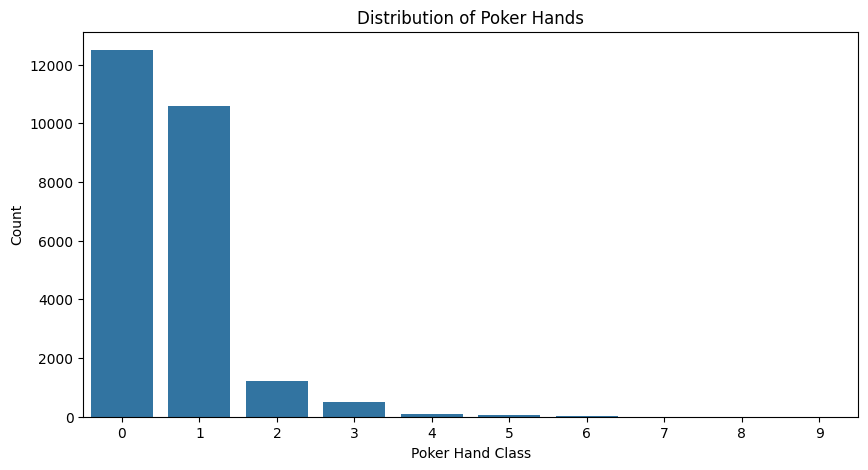

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(x="hand", data=df)
plt.title("Distribution of Poker Hands")
plt.xlabel("Poker Hand Class")
plt.ylabel("Count")
plt.show()


In [32]:
print("Unique suits:", sorted(df[[f"S{i}" for i in range(1, 6)]].stack().unique()))
print("Unique ranks:", sorted(df[[f"R{i}" for i in range(1, 6)]].stack().unique()))


Unique suits: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique ranks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


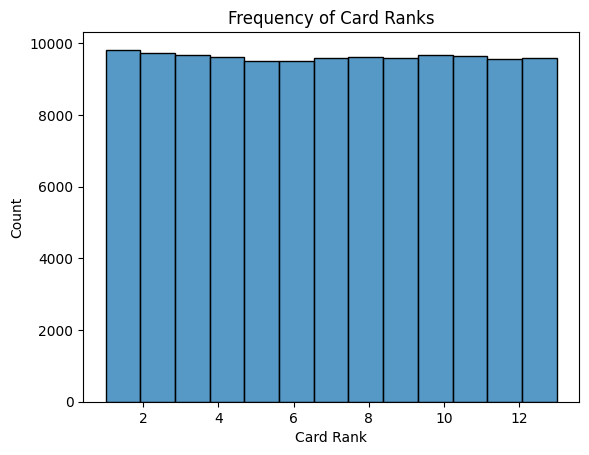

In [33]:
ranks = df[[f"R{i}" for i in range(1, 6)]].values.flatten()
sns.histplot(ranks, bins=13, kde=False)
plt.title("Frequency of Card Ranks")
plt.xlabel("Card Rank")
plt.ylabel("Count")
plt.show()


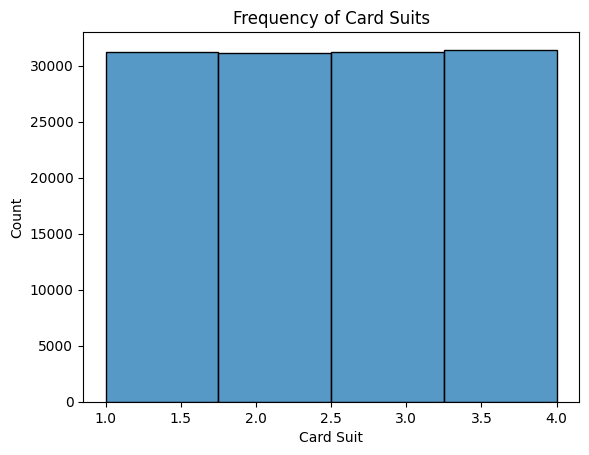

In [34]:
suits = df[[f"S{i}" for i in range(1, 6)]].values.flatten()
sns.histplot(suits, bins=4, kde=False)
plt.title("Frequency of Card Suits")
plt.xlabel("Card Suit")
plt.ylabel("Count")
plt.show()


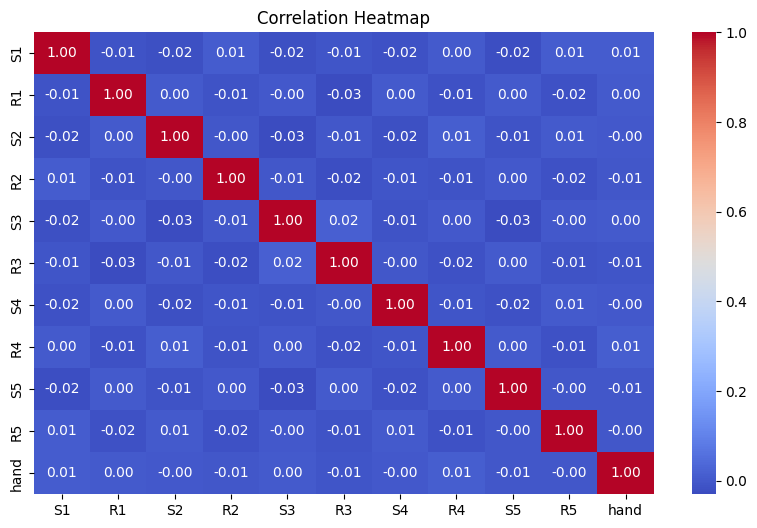

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Encoding so that model does not think one suit/rank is better than other.

In [39]:
import numpy as np

def one_hot_encode_hand(X):
    """
    X is shape (n_samples, 10) where:
    - X[:, 0] = S1, X[:, 1] = R1, ..., X[:, 8] = S5, X[:, 9] = R5
    Returns one-hot encoded features of shape (n_samples, 85)
    """
    n_samples = X.shape[0]
    encoded = np.zeros((n_samples, 85), dtype=int)

    for i in range(5):  # for each card (S1–R5)
        suit_col = 2 * i
        rank_col = 2 * i + 1

        suit_indices = X[:, suit_col] - 1     # suits: 1–4 → 0–3
        rank_indices = X[:, rank_col] - 1     # ranks: 1–13 → 0–12

        # Offset to place one-hots in right part of vector
        suit_offset = i * 17
        rank_offset = suit_offset + 4

        for j in range(n_samples):
            encoded[j, suit_offset + suit_indices[j]] = 1
            encoded[j, rank_offset + rank_indices[j]] = 1

    return encoded


In [40]:
X_train_encoded = one_hot_encode_hand(X_train)
X_test_encoded = one_hot_encode_hand(X_test)

print("Encoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)


Encoded X_train shape: (25010, 85)
Encoded X_test shape: (1000000, 85)


In [41]:
print("Original:", X_train[0])
print("Encoded:", X_train_encoded[0])


Original: [ 1 10  1 11  1 13  1 12  1  1]
Encoded: [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0]


Epoch 1, LR: 0.1000, Accuracy: 0.4962
Epoch 2, LR: 0.0990, Accuracy: 0.4701
Epoch 3, LR: 0.0980, Accuracy: 0.5030
Epoch 4, LR: 0.0971, Accuracy: 0.4976
Epoch 5, LR: 0.0962, Accuracy: 0.5349
Epoch 6, LR: 0.0952, Accuracy: 0.5492
Epoch 7, LR: 0.0943, Accuracy: 0.5685
Epoch 8, LR: 0.0935, Accuracy: 0.5629
Epoch 9, LR: 0.0926, Accuracy: 0.6055
Epoch 10, LR: 0.0917, Accuracy: 0.6570
Epoch 11, LR: 0.0909, Accuracy: 0.6635
Epoch 12, LR: 0.0901, Accuracy: 0.7429
Epoch 13, LR: 0.0893, Accuracy: 0.8154
Epoch 14, LR: 0.0885, Accuracy: 0.7041
Epoch 15, LR: 0.0877, Accuracy: 0.8273
Epoch 16, LR: 0.0870, Accuracy: 0.9330
Epoch 17, LR: 0.0862, Accuracy: 0.9197
Epoch 18, LR: 0.0855, Accuracy: 0.9508
Epoch 19, LR: 0.0847, Accuracy: 0.9623
Epoch 20, LR: 0.0840, Accuracy: 0.9699
Epoch 21, LR: 0.0833, Accuracy: 0.9619
Epoch 22, LR: 0.0826, Accuracy: 0.9791
Epoch 23, LR: 0.0820, Accuracy: 0.9780
Epoch 24, LR: 0.0813, Accuracy: 0.9783
Epoch 25, LR: 0.0806, Accuracy: 0.9721
Epoch 26, LR: 0.0800, Accuracy: 0.

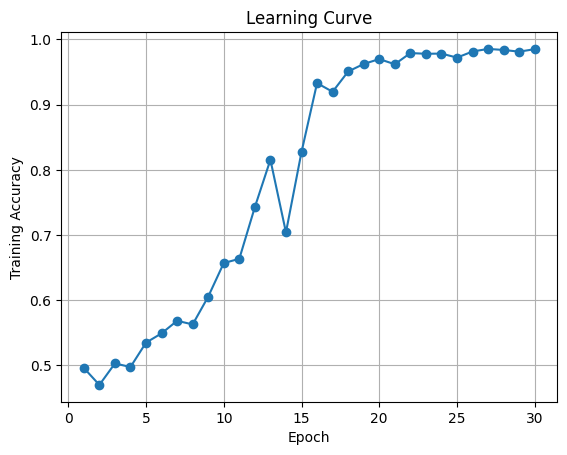

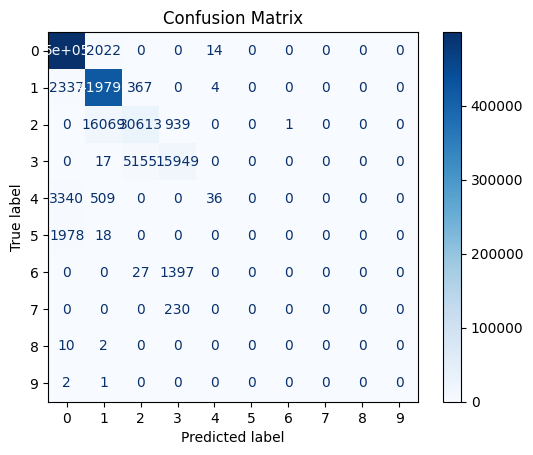

In [42]:
nn = NeuralNetwork(input_dim=85, hidden_dims=[64, 64], output_dim=10)
trainer = Trainer(nn, lr=0.1, epochs=30, batch_size=64, lr_decay=0.01)

trainer.train(X_train_encoded, y_train)
y_pred = trainer.evaluate(X_test_encoded, y_test)
trainer.plot_learning_curve()
trainer.plot_confusion(y_test, y_pred)


Struggles with low represented classes, from 5 to 9. Else good results.

nn = NeuralNetwork(
    input_dim=85,
    hidden_dims=[64, 64],         # Two hidden layers
    output_dim=10
)

trainer = Trainer(
    model=nn,
    lr=0.1,
    epochs=30,
    batch_size=64,
    lr_decay=0.01                 # Adaptive LR η = η₀ / √e
)
This is best model so far

In [44]:
hidden_units = [5, 10, 15, 20, 25]
results = []

for h in hidden_units:
    nn = NeuralNetwork(input_dim=85, hidden_dims=[h], output_dim=10)
    trainer = Trainer(nn, lr=0.1, epochs=30, batch_size=100, lr_decay=0.01)
    trainer.train(X_train_encoded, y_train)
    test_preds = trainer.evaluate(X_test_encoded, y_test)
    acc = np.mean(test_preds == y_test)
    results.append(acc)


Epoch 1, LR: 0.1000, Accuracy: 0.4990
Epoch 2, LR: 0.0990, Accuracy: 0.4257
Epoch 3, LR: 0.0980, Accuracy: 0.5020
Epoch 4, LR: 0.0971, Accuracy: 0.5029
Epoch 5, LR: 0.0962, Accuracy: 0.5069
Epoch 6, LR: 0.0952, Accuracy: 0.5020
Epoch 7, LR: 0.0943, Accuracy: 0.5062
Epoch 8, LR: 0.0935, Accuracy: 0.4238
Epoch 9, LR: 0.0926, Accuracy: 0.5190
Epoch 10, LR: 0.0917, Accuracy: 0.5385
Epoch 11, LR: 0.0909, Accuracy: 0.5427
Epoch 12, LR: 0.0901, Accuracy: 0.5446
Epoch 13, LR: 0.0893, Accuracy: 0.5612
Epoch 14, LR: 0.0885, Accuracy: 0.5566
Epoch 15, LR: 0.0877, Accuracy: 0.5599
Epoch 16, LR: 0.0870, Accuracy: 0.4671
Epoch 17, LR: 0.0862, Accuracy: 0.5324
Epoch 18, LR: 0.0855, Accuracy: 0.5880
Epoch 19, LR: 0.0847, Accuracy: 0.5822
Epoch 20, LR: 0.0840, Accuracy: 0.5787
Epoch 21, LR: 0.0833, Accuracy: 0.5926
Epoch 22, LR: 0.0826, Accuracy: 0.5988
Epoch 23, LR: 0.0820, Accuracy: 0.5929
Epoch 24, LR: 0.0813, Accuracy: 0.6102
Epoch 25, LR: 0.0806, Accuracy: 0.6131
Epoch 26, LR: 0.0800, Accuracy: 0.

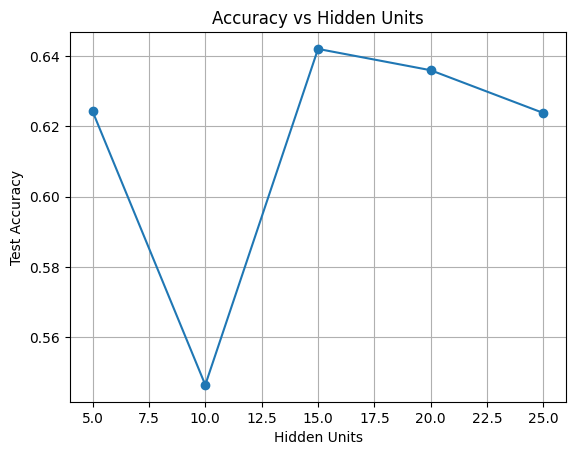

In [45]:
plt.plot(hidden_units, results, marker='o')
plt.title("Accuracy vs Hidden Units")
plt.xlabel("Hidden Units")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()


Working really bad with more hidden layers. So 2 hidden layers is best.

In [46]:
hidden_dims = [64, 64]
input_dim = 85
output_dim = 10
epochs = 30
lr = 0.1
batch_size = 64


for ReLU

Epoch 1, LR: 0.1000, Accuracy: 0.5028
Epoch 2, LR: 0.0990, Accuracy: 0.5010
Epoch 3, LR: 0.0980, Accuracy: 0.5253
Epoch 4, LR: 0.0971, Accuracy: 0.5295
Epoch 5, LR: 0.0962, Accuracy: 0.5315
Epoch 6, LR: 0.0952, Accuracy: 0.5323
Epoch 7, LR: 0.0943, Accuracy: 0.5442
Epoch 8, LR: 0.0935, Accuracy: 0.6091
Epoch 9, LR: 0.0926, Accuracy: 0.6519
Epoch 10, LR: 0.0917, Accuracy: 0.7002
Epoch 11, LR: 0.0909, Accuracy: 0.7451
Epoch 12, LR: 0.0901, Accuracy: 0.7858
Epoch 13, LR: 0.0893, Accuracy: 0.8321
Epoch 14, LR: 0.0885, Accuracy: 0.7855
Epoch 15, LR: 0.0877, Accuracy: 0.9136
Epoch 16, LR: 0.0870, Accuracy: 0.8338
Epoch 17, LR: 0.0862, Accuracy: 0.9602
Epoch 18, LR: 0.0855, Accuracy: 0.9708
Epoch 19, LR: 0.0847, Accuracy: 0.9739
Epoch 20, LR: 0.0840, Accuracy: 0.9690
Epoch 21, LR: 0.0833, Accuracy: 0.9786
Epoch 22, LR: 0.0826, Accuracy: 0.9784
Epoch 23, LR: 0.0820, Accuracy: 0.9802
Epoch 24, LR: 0.0813, Accuracy: 0.9853
Epoch 25, LR: 0.0806, Accuracy: 0.9841
Epoch 26, LR: 0.0800, Accuracy: 0.

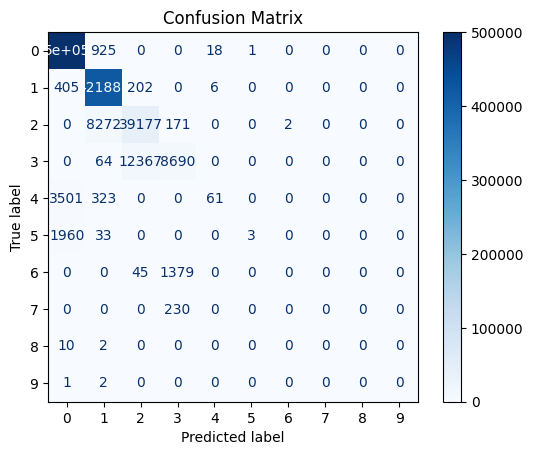

In [47]:
nn_relu = NeuralNetwork(input_dim, hidden_dims, output_dim)
trainer_relu = Trainer(nn_relu, lr=lr, epochs=epochs, batch_size=batch_size, lr_decay=0.01)

trainer_relu.train(X_train_encoded, y_train)
y_pred_relu = trainer_relu.evaluate(X_test_encoded, y_test)
trainer_relu.plot_confusion(y_test, y_pred_relu)


for Sigmoid

Epoch 1, LR: 0.1000, Accuracy: 0.4238
Epoch 2, LR: 0.0990, Accuracy: 0.4995
Epoch 3, LR: 0.0980, Accuracy: 0.5013
Epoch 4, LR: 0.0971, Accuracy: 0.4239
Epoch 5, LR: 0.0962, Accuracy: 0.4995
Epoch 6, LR: 0.0952, Accuracy: 0.4238
Epoch 7, LR: 0.0943, Accuracy: 0.4240
Epoch 8, LR: 0.0935, Accuracy: 0.4999
Epoch 9, LR: 0.0926, Accuracy: 0.4291
Epoch 10, LR: 0.0917, Accuracy: 0.4995
Epoch 11, LR: 0.0909, Accuracy: 0.4995
Epoch 12, LR: 0.0901, Accuracy: 0.4995
Epoch 13, LR: 0.0893, Accuracy: 0.4995
Epoch 14, LR: 0.0885, Accuracy: 0.4995
Epoch 15, LR: 0.0877, Accuracy: 0.5001
Epoch 16, LR: 0.0870, Accuracy: 0.4995
Epoch 17, LR: 0.0862, Accuracy: 0.4661
Epoch 18, LR: 0.0855, Accuracy: 0.5006
Epoch 19, LR: 0.0847, Accuracy: 0.4995
Epoch 20, LR: 0.0840, Accuracy: 0.4995
Epoch 21, LR: 0.0833, Accuracy: 0.4995
Epoch 22, LR: 0.0826, Accuracy: 0.4995
Epoch 23, LR: 0.0820, Accuracy: 0.4995
Epoch 24, LR: 0.0813, Accuracy: 0.4823
Epoch 25, LR: 0.0806, Accuracy: 0.4995
Epoch 26, LR: 0.0800, Accuracy: 0.

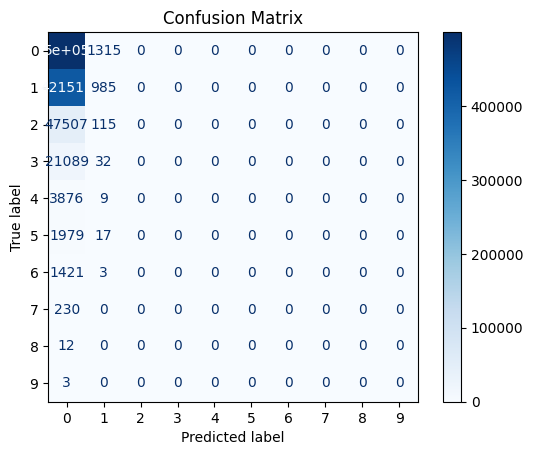

In [48]:
nn_sigmoid = NeuralNetwork(input_dim, hidden_dims, output_dim)
# manually overwrite activations
for i in range(len(nn_sigmoid.activations) - 1):
    nn_sigmoid.activations[i] = "sigmoid"

trainer_sigmoid = Trainer(nn_sigmoid, lr=lr, epochs=epochs, batch_size=batch_size, lr_decay=0.01)

trainer_sigmoid.train(X_train_encoded, y_train)
y_pred_sigmoid = trainer_sigmoid.evaluate(X_test_encoded, y_test)
trainer_sigmoid.plot_confusion(y_test, y_pred_sigmoid)


ReLU better than Sigmoid

With sklearn MLP Classifier

Sklearn Test Accuracy: 0.993246


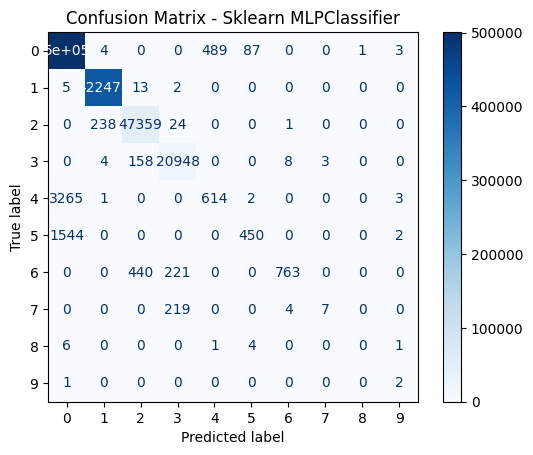

In [49]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instantiate the model
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='sgd',
    batch_size=64,
    learning_rate_init=0.1,
    max_iter=30,
    random_state=42
)

# Fit the model
mlp.fit(X_train_encoded, y_train)

# Predict
y_pred_sklearn = mlp.predict(X_test_encoded)

# Accuracy
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print("Sklearn Test Accuracy:", acc_sklearn)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_sklearn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Sklearn MLPClassifier")
plt.show()


Very high test accuracy, worked well with under represented classes too.